# Notebook 05 — Modeling & Evaluation
## Machine Learning-based Late Delivery Risk Prediction in Global Supply Chain Operations
**Client:** APL Logistics (KWE Group) | **Platform:** Unified Mentor

### Objective
This notebook trains three classification models using a dictionary-based loop, performs 5-fold cross validation, applies hyperparameter tuning on the best model, evaluates all models, plots feature importance, and saves all trained models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
MODELS_PATH = '../models/'
FIG_PATH = '../reports/eda_figures/'
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)

print("Imports successful.")

Imports successful.


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train shape: (144413, 29)
X_test shape:  (36104, 29)
y_train distribution:
Late_delivery_risk
1    79180
0    65233
Name: count, dtype: int64

y_test distribution:
Late_delivery_risk
1    19796
0    16308
Name: count, dtype: int64


## Define Models Dictionary
All three models defined in a single dictionary. class_weight='balanced' handles the slight class imbalance without SMOTE.

In [3]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

print("Models defined:")
for name in models:
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Random Forest
  - XGBoost


##  Baseline Training & Cross Validation Loop
Training all models and performing 5-fold cross validation on X_train. Cross validation is done on training data only — test set is untouched.

In [4]:
cv_results = {}

print("=" * 60)
print("BASELINE TRAINING & 5-FOLD CROSS VALIDATION")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining: {name}")
    
    # Train on full X_train
    model.fit(X_train, y_train)
    
    # 5-fold CV on X_train
    cv_roc = cross_val_score(model, X_train, y_train,
                              cv=5, scoring='roc_auc', n_jobs=-1)
    cv_f1 = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='f1', n_jobs=-1)
    
    cv_results[name] = {
        'model': model,
        'cv_roc_auc_mean': cv_roc.mean(),
        'cv_roc_auc_std': cv_roc.std(),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std()
    }
    
    print(f"  CV ROC-AUC: {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
    print(f"  CV F1:      {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

print("\nBaseline training complete.")

BASELINE TRAINING & 5-FOLD CROSS VALIDATION

Training: Logistic Regression
  CV ROC-AUC: 0.9803 ± 0.0008
  CV F1:      0.9749 ± 0.0019

Training: Random Forest
  CV ROC-AUC: 0.9964 ± 0.0002
  CV F1:      0.9786 ± 0.0004

Training: XGBoost
  CV ROC-AUC: 0.9964 ± 0.0001
  CV F1:      0.9792 ± 0.0005

Baseline training complete.


##  Baseline Test Set Evaluation
Evaluating all models on X_test to get baseline performance metrics.

In [5]:
baseline_results = {}

print("=" * 60)
print("BASELINE TEST SET EVALUATION")
print("=" * 60)

for name, result in cv_results.items():
    model = result['model']
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    baseline_results[name] = {
        'model': model,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'cv_roc_auc_mean': result['cv_roc_auc_mean'],
        'cv_roc_auc_std':  result['cv_roc_auc_std'],
        'cv_f1_mean': result['cv_f1_mean'],
        'cv_f1_std':  result['cv_f1_std']
    }
    
    print(f"\n{name}")
    print(f"  Accuracy:  {baseline_results[name]['accuracy']:.4f}")
    print(f"  Precision: {baseline_results[name]['precision']:.4f}")
    print(f"  Recall:    {baseline_results[name]['recall']:.4f}")
    print(f"  F1 Score:  {baseline_results[name]['f1']:.4f}")
    print(f"  ROC-AUC:   {baseline_results[name]['roc_auc']:.4f}")

BASELINE TEST SET EVALUATION

Logistic Regression
  Accuracy:  0.9740
  Precision: 0.9589
  Recall:    0.9952
  F1 Score:  0.9767
  ROC-AUC:   0.9806

Random Forest
  Accuracy:  0.9773
  Precision: 0.9604
  Recall:    0.9998
  F1 Score:  0.9797
  ROC-AUC:   0.9970

XGBoost
  Accuracy:  0.9781
  Precision: 0.9633
  Recall:    0.9980
  F1 Score:  0.9804
  ROC-AUC:   0.9969


##  Baseline Comparison Table

In [6]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy':        round(res['accuracy'], 4),
        'Precision':       round(res['precision'], 4),
        'Recall':          round(res['recall'], 4),
        'F1 Score':        round(res['f1'], 4),
        'ROC-AUC':         round(res['roc_auc'], 4),
        'CV ROC-AUC Mean': round(res['cv_roc_auc_mean'], 4),
        'CV ROC-AUC Std':  round(res['cv_roc_auc_std'], 4),
        'CV F1 Mean':      round(res['cv_f1_mean'], 4),
        'CV F1 Std':       round(res['cv_f1_std'], 4),
    }
    for name, res in baseline_results.items()
}).T

print("BASELINE MODEL COMPARISON TABLE")
display(comparison_df)

BASELINE MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC Std,CV F1 Mean,CV F1 Std
Logistic Regression,0.9740,0.9589,0.9952,0.9767,0.9806,0.9803,0.0008,0.9749,0.0019
Random Forest,0.9773,0.9604,0.9998,0.9797,0.9970,0.9964,0.0002,0.9786,0.0004
XGBoost,0.9781,0.9633,0.9980,0.9804,0.9969,0.9964,0.0001,0.9792,0.0005


##  Hyperparameter Tuning — Best Baseline Model
Based on baseline ROC-AUC, we apply RandomizedSearchCV to the best performing model. RandomizedSearchCV is chosen over GridSearchCV because of the large dataset size — it samples a fixed number of parameter combinations rather than exhaustively trying all, giving good results much faster.

In [7]:
# XGBoost parameter grid
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running RandomizedSearchCV — this may take a few minutes...")
random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")

Running RandomizedSearchCV — this may take a few minutes...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.9967


##  Evaluate Tuned Model on Test Set

In [8]:
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_results = {
    'accuracy':  accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall':    recall_score(y_test, y_pred_tuned),
    'f1':        f1_score(y_test, y_pred_tuned),
    'roc_auc':   roc_auc_score(y_test, y_prob_tuned)
}

print("TUNED XGBOOST — TEST SET RESULTS")
print("=" * 40)
for metric, value in tuned_results.items():
    print(f"  {metric.capitalize()}: {value:.4f}")

TUNED XGBOOST — TEST SET RESULTS
  Accuracy: 0.9787
  Precision: 0.9644
  Recall: 0.9980
  F1: 0.9809
  Roc_auc: 0.9972


##  Final Model Comparison Table

In [9]:
final_comparison = comparison_df.copy()
final_comparison.loc['XGBoost (Tuned)'] = {
    'Accuracy':        round(tuned_results['accuracy'], 4),
    'Precision':       round(tuned_results['precision'], 4),
    'Recall':          round(tuned_results['recall'], 4),
    'F1 Score':        round(tuned_results['f1'], 4),
    'ROC-AUC':         round(tuned_results['roc_auc'], 4),
    'CV ROC-AUC Mean': round(random_search.best_score_, 4),
    'CV ROC-AUC Std':  '-',
    'CV F1 Mean':      '-',
    'CV F1 Std':       '-'
}

print("FINAL MODEL COMPARISON TABLE")
display(final_comparison)

FINAL MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC Std,CV F1 Mean,CV F1 Std
Logistic Regression,0.9740,0.9589,0.9952,0.9767,0.9806,0.9803,0.0008,0.9749,0.0019
Random Forest,0.9773,0.9604,0.9998,0.9797,0.9970,0.9964,0.0002,0.9786,0.0004
XGBoost,0.9781,0.9633,0.9980,0.9804,0.9969,0.9964,0.0001,0.9792,0.0005
XGBoost (Tuned),0.9787,0.9644,0.9980,0.9809,0.9972,0.9967,-,-,-


##  Confusion Matrices

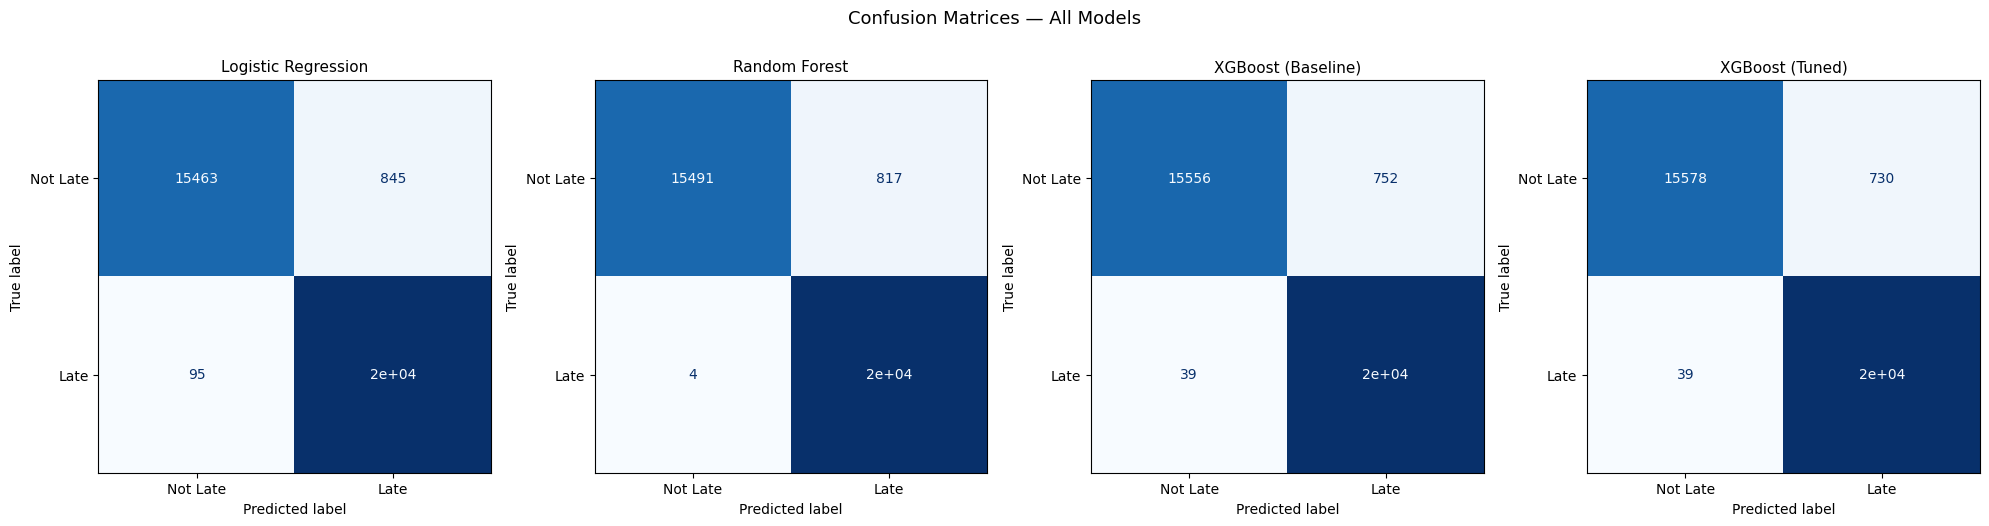

Saved: 12_confusion_matrices.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_to_plot = {
    'Logistic Regression': (baseline_results['Logistic Regression']['model'],
                             baseline_results['Logistic Regression']['model'].predict(X_test)),
    'Random Forest':       (baseline_results['Random Forest']['model'],
                             baseline_results['Random Forest']['model'].predict(X_test)),
    'XGBoost (Baseline)':  (baseline_results['XGBoost']['model'],
                             baseline_results['XGBoost']['model'].predict(X_test)),
    'XGBoost (Tuned)':     (best_model, y_pred_tuned)
}

for ax, (name, (model, y_pred)) in zip(axes, models_to_plot.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Not Late', 'Late'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + '12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 12_confusion_matrices.png")

##  Feature Importance

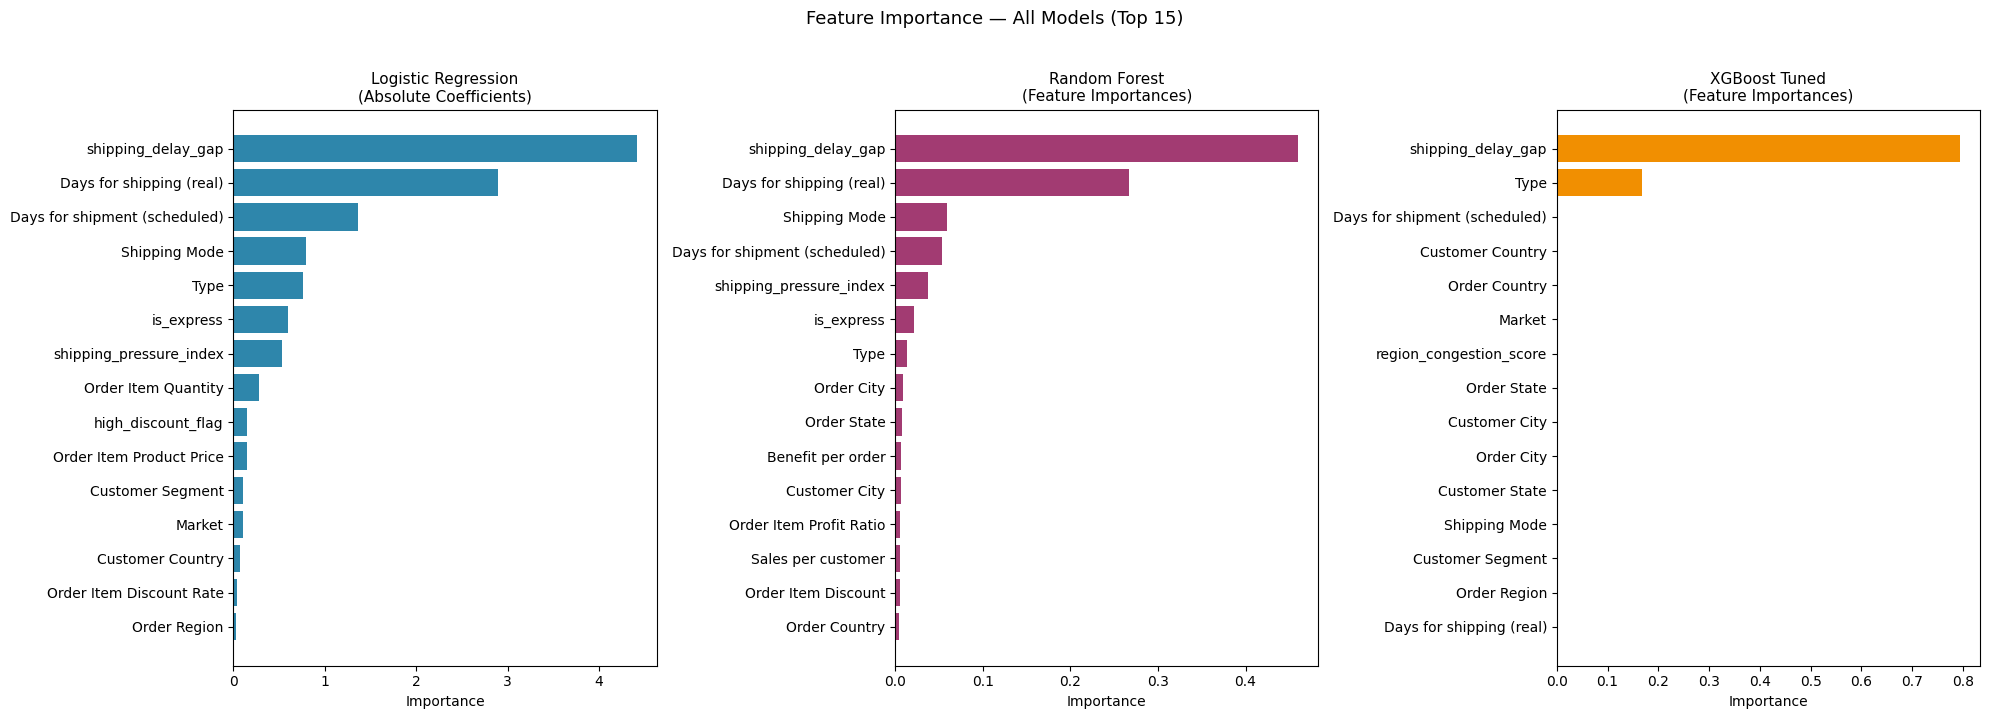

Saved: 13_feature_importance.png


In [11]:
feature_names = X_train.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Logistic Regression — coefficients
lr_importance = pd.Series(
    np.abs(baseline_results['Logistic Regression']['model'].coef_[0]),
    index=feature_names
).sort_values(ascending=True).tail(15)

axes[0].barh(lr_importance.index, lr_importance.values, color=COLORS[0])
axes[0].set_title('Logistic Regression\n(Absolute Coefficients)', fontsize=11)
axes[0].set_xlabel('Importance')

# Random Forest — feature importances
rf_importance = pd.Series(
    baseline_results['Random Forest']['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=True).tail(15)

axes[1].barh(rf_importance.index, rf_importance.values, color=COLORS[1])
axes[1].set_title('Random Forest\n(Feature Importances)', fontsize=11)
axes[1].set_xlabel('Importance')

# XGBoost Tuned — feature importances
xgb_importance = pd.Series(
    best_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True).tail(15)

axes[2].barh(xgb_importance.index, xgb_importance.values, color=COLORS[2])
axes[2].set_title('XGBoost Tuned\n(Feature Importances)', fontsize=11)
axes[2].set_xlabel('Importance')

plt.suptitle('Feature Importance — All Models (Top 15)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + '13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 13_feature_importance.png")

##  Save All Models

In [12]:
# Save individual models
joblib.dump(baseline_results['Logistic Regression']['model'],
            MODELS_PATH + 'logistic_regression.pkl')
joblib.dump(baseline_results['Random Forest']['model'],
            MODELS_PATH + 'random_forest.pkl')
joblib.dump(baseline_results['XGBoost']['model'],
            MODELS_PATH + 'xgboost_baseline.pkl')
joblib.dump(best_model,
            MODELS_PATH + 'xgboost_tuned.pkl')

# Save best model separately for the app
joblib.dump(best_model, MODELS_PATH + 'best_model.pkl')

print("Saved: models/logistic_regression.pkl")
print("Saved: models/random_forest.pkl")
print("Saved: models/xgboost_baseline.pkl")
print("Saved: models/xgboost_tuned.pkl")
print("Saved: models/best_model.pkl")

Saved: models/logistic_regression.pkl
Saved: models/random_forest.pkl
Saved: models/xgboost_baseline.pkl
Saved: models/xgboost_tuned.pkl
Saved: models/best_model.pkl


##  Modeling Summary

In [13]:
print("=" * 60)
print("MODELING SUMMARY")
print("=" * 60)
print(f"\nModels trained:          3 (LR, RF, XGBoost)")
print(f"Cross validation:        5-fold on X_train only")
print(f"Hyperparameter tuning:   RandomizedSearchCV (30 iterations)")
print(f"Tuning metric:           ROC-AUC")
print(f"Best parameters:         {random_search.best_params_}")
print(f"\nBest model:              XGBoost (Tuned)")
print(f"Best CV ROC-AUC:         {random_search.best_score_:.4f}")
print(f"Test ROC-AUC:            {tuned_results['roc_auc']:.4f}")
print(f"Test F1 Score:           {tuned_results['f1']:.4f}")
print(f"Test Accuracy:           {tuned_results['accuracy']:.4f}")
print(f"\nSaved to models/:        logistic_regression.pkl, random_forest.pkl,")
print(f"                         xgboost_baseline.pkl, xgboost_tuned.pkl, best_model.pkl")

MODELING SUMMARY

Models trained:          3 (LR, RF, XGBoost)
Cross validation:        5-fold on X_train only
Hyperparameter tuning:   RandomizedSearchCV (30 iterations)
Tuning metric:           ROC-AUC
Best parameters:         {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Best model:              XGBoost (Tuned)
Best CV ROC-AUC:         0.9967
Test ROC-AUC:            0.9972
Test F1 Score:           0.9809
Test Accuracy:           0.9787

Saved to models/:        logistic_regression.pkl, random_forest.pkl,
                         xgboost_baseline.pkl, xgboost_tuned.pkl, best_model.pkl
